# Single Variable Calculus 

## draft version of notes
**disclaimer: these notes are very much in their initial stages, typos and erros may be present.**
**notice: you do not have permission to distribute these notes** 

## Derivatives 
The truth is you don't need that much calculus for machine learning. Hooray! We rarely need to use the integral, so I won't even cover that here. Derivatives are important. But the least important thing about a derivative is all those rules you memorized to compute the derivative (product rule, quotient rule, etc). **The most important thing is understanding the concept of the derivative.** 

The derivative of $f(x)$ is 
\begin{equation} 
\frac{df}{dx} = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}. 
\end{equation} 

Conceptually, a good way to understand the derivative is 
\begin{equation} 
\frac{df}{dx} = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x} = \text{the slope of the line tangent to the $f(x)$ curve} . 
\end{equation} 

In [4]:
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt 
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML


import sympy as sym 
from scipy.special import factorial 

from IPython.display import Javascript, HTML, display
%load_ext jsxgraph-magic

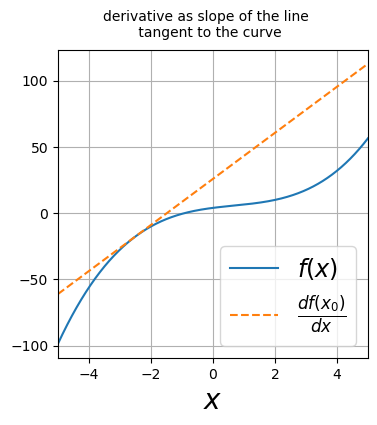

In [5]:
f = lambda x: .5*x**3 -x**2 +3*x + 4
df = lambda x: 1.5*x**2-2*x +3 

x=np.linspace(-5,5,1000) 

# Point at which to calculate the tangent line 
x0 = -2.5
y0 = f(x0)

# Slope of the tangent line at x = x0
slope = df(x0)

tangent =slope*(x - x0) + y0

fig = plt.figure(figsize=(4,4))
fig.suptitle("derivative as slope of the line \n tangent to the curve", size=10) 
ax = fig.add_subplot()
ax.set_xlim(x[0], x[-1]) 
ax.set_xlabel(r"$x$", size=20) 
ax.plot(x, f(x), label=r"$f(x)$")
ax.plot(x, tangent,"--", label=r"$\frac{df(x_0)}{dx}$" ) 
ax.legend(loc=4, fontsize="xx-large") 
ax.grid()



Above is a plot illustrating the slope of the line tangent to the curve. **Below** is an interactive plot to visualize the derivative as the slope of the line tangent to the curve. With your cursor, grab the red dot labeled $x_0$ and drag it along the x-axis. The slope of the line tangent to the curve will be shown for each point you slide across. 

In [6]:
%%jsxgraph -w 600 -h 400 df_tangent
    var board = JXG.JSXGraph.initBoard('df_tangent', {boundingbox: [-3, 5, 3, -8],axis: true });
// 1. Define the Function and its Derivative
        const f = function(x) {
            return .3*x**4 - .1*x**3 -2*x**2 -.8*x -2; // Example function: f(x) = 0.5x^2 - 2
        };
        const fPrime = function(x) {
            return 1.2*x**3-.3*x**2 -4*x -.8;             // Derivative of f(x)
        };
        //var fPrime = JXG.Math.Numerics.D(f);  // Alternative: Numerical derivative

        // 2. Plot the Function
        var graph = board.create('functiongraph', [f, -3, 3], {
            strokeColor: 'blue',
            strokeWidth: 2,
            name: 'f(x)',
            withLabel: true
        });

        // 3. Create a Point on the Curve
        var xPoint = board.create('glider', [0, 0, board.defaultAxes.x], {
            name: 'x0',
            size: 3,
            color: 'red',
            label: {fontSize: 18}
        });
        var pointOnCurve = board.create('point', [
            function() { return xPoint.X(); },
            function() { return f(xPoint.X()); }
        ], {
            name: 'f(x_0)',
            color: 'black',
            fixed: true, 
            label: {fontSize: 18},
        });

        // 4. Calculate the Tangent Line Slope
        const getTangentSlope = function() {
            return fPrime(xPoint.X());
        };

        // 5. Display the Slope as a Tangent Line
        var tangentLine = board.create('line', [pointOnCurve, [
            function() { return xPoint.X() + 1; },  // A point slightly to the right
            function() { return f(xPoint.X()) + getTangentSlope(); } // y = f(x0) + f'(x0)
        ]], {
            strokeColor: 'green',
            strokeWidth: 2,
            name: 'tangent',
            withLabel: false
        });

        // 6. Display the Slope Value as Text
        var slopeText = board.create('text', [-2, 4, function() {
            return "Slope: " + getTangentSlope().toFixed(2);
        }], {
            anchorX: 'left',
            anchorY: 'top',
            fontSize: 16,
            color: 'green'
        });
        

      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

We now build our **intuition for the limit**. Imagine evaluating the function at two points, $x_0$ and $x_0 + \Delta x$; $f(x_0)$ and $f(x_0 + \Delta x)$. We subtract the two and divide by $\Delta x$, to obtain the slope $\frac{f(x_0 + \Delta x) - f(x_0)}{\Delta x}$. We then take $\Delta x$ to zero. The animation below illustrates this idea, by continuously decreasing $\Delta x$. As $\Delta x$ approaches zero, the slope,$\frac{f(x_0 + \Delta x) - f(x_0)}{\Delta x}$,   eventually becomes the line tangent to the curve. 

In [7]:

# -------------------- animation code ------------------------------

# function evaluated at x0
f0= f(x0) 
# array of dx values 
dx=np.array([3, 3/2, 3/4, 3/8, 3/16, 3/32]) 
n_frames = dx.size 

fig = plt.figure(figsize=(6,6))
fig.suptitle("annimating the limit concept", size=30) 
ax = fig.add_subplot()
ax.set_xlim(x[0], x[-1]) 
ax.set_xlabel(r"$x$", size=20) 
ax.plot(x, f(x), label=r"$f(x)$")

y_offset = 10 # for plotting labe underneath the point
ax.plot([x0], [f0-y_offset], marker=r"$f(x_0)$", markersize=30, color="black", alpha=.5)

ln, =ax.plot([], [], alpha =.5) 
pts, = ax.plot([], [], "o", color="red") 
txt, =ax.plot([], [], marker=r"$f(x_0 + \Delta x)$", markersize=60, color="black", alpha=.5)

ax.grid()
plt.tight_layout()
plt.close()

def init(): 

    ln.set_data([], []) 
    pts.set_data([], []) 
    txt.set_data([], []) 
    return ln, pts, txt, 

def draw(i): 

    x1= x0 + dx[i] 
    f1=f(x1) 

    slope = (f1-f0)/dx[i]

    tangent =slope*(x - x0) + y0
    
    ln.set_data(x, tangent) 

    pts.set_data([x0, x1], [f0, f1]) 

    txt.set_data([x1], [f1 + y_offset]) 
    
    return ln, pts, txt, 

anim = animation.FuncAnimation(fig, draw, frames=n_frames, interval=500, blit=True)

In [8]:
HTML(anim.to_html5_video())

**The "slope of the line tangent to the curve" provides much information**. Here are some ideas worth remembering: 
* if the slope is positive, the derivative is positive, this indicates that the function is increasing with increasing $x$
* if the slope is negative, the derivative is negative, this indicates that the function is decreasing with increasing $x$
* if the slope is zero, the derivative is zero, this is where the function is a minimum or maximum 



### Steps to Find Minima and Maxima Using Derivatives

#### 1. **First Derivative**
To find the **minima** and **maxima**, we look for points where the slope of the line tangent to the curve is zero, i.e., where the **first derivative equals zero**.

Let the function be $f(x)$. Minima and maxima points are called extrema and they satisfy

$$
f'(x) = 0.
$$

#### 2. **Second Derivative Test**

Once we have the extrema points from the first derivative, we use the **second derivative** to determine whether these points correspond to minima, maxima.

- **Second Derivative Test**:
  - If $f''(x) > 0$ at a critical point, the function is **concave up** at that point, and it is a **local minimum**.
  - If $f''(x) < 0$ at a critical point, the function is **concave down** at that point, and it is a **local maximum**.
  - If $f''(x) = 0$, the test is **inconclusive**. The curvature may change — this could be a point of inflection.

#### Example 

Consider the function:

$$
f(x) = x^3 - 3x^2 + 4
$$

##### Step 1: Find the first derivative

$$
f'(x) = 3x^2 - 6x
$$

##### Step 2: Set the first derivative equal to zero to find the critical points

$$
3x^2 - 6x = 0
$$

Factor the equation:

$$
3x(x - 2) = 0
$$

The critical points are:

$$
x = 0 \quad \text{or} \quad x = 2
$$

##### Step 3: Find the second derivative

$$
f''(x) = 6x - 6
$$

##### Step 4: Use the second derivative to classify the critical points

- For $x = 0$:

$$
f''(0) = 6(0) - 6 = -6
$$

Since $f''(0) < 0$, $x = 0$ is a **local maximum**.

- For $x = 2$:

$$
f''(2) = 6(2) - 6 = 6
$$

Since $f''(2) > 0$, $x = 2$ is a **local minimum**.

Thus, $f(x) = x^3 - 3x^2 + 4$ has a local maximum at $x = 0$ and a local minimum at $x = 2$.

### Graphical Interpretation

- **local maximum**: The function curve is "bending down" (concave down) at this point, meaning the point is higher than all nearby points.
- **local minimum**: The function curve is "bending up" (concave up) at this point, meaning the point is lower than all nearby points.
- A **global maximum**, is the maximum which is larger than all the other maximum. Likewise a **global minimum**, is a minimum which is less than all the other minimum. 

The plot below illustrates the relation between extrema, derivatives, and curvature. 

* The leftmost panel is the function $f(x)=0.3x^4 - 0.1x^3 -2.0x^2 -0.8x$. The three red dots plot the locations of the extrema: a local maximum, a local minimum, and a global minimum. 
* The middle panel plots the first derivative. The three red dots are the roots of the derivative. 
* The right panel plots the second derivative. The second derivative is positive at the two minima, indicating the function is curving up, convex. The derivative is negative at the maximum, indicating the function is curving down, concave. The same three red dots from the left and middle panels are also included. 
SymPy was used to take derivatives and find the roots of the derivative. 

extrema values [-1.58634606362263 -0.205790802216379 2.04213686583901]


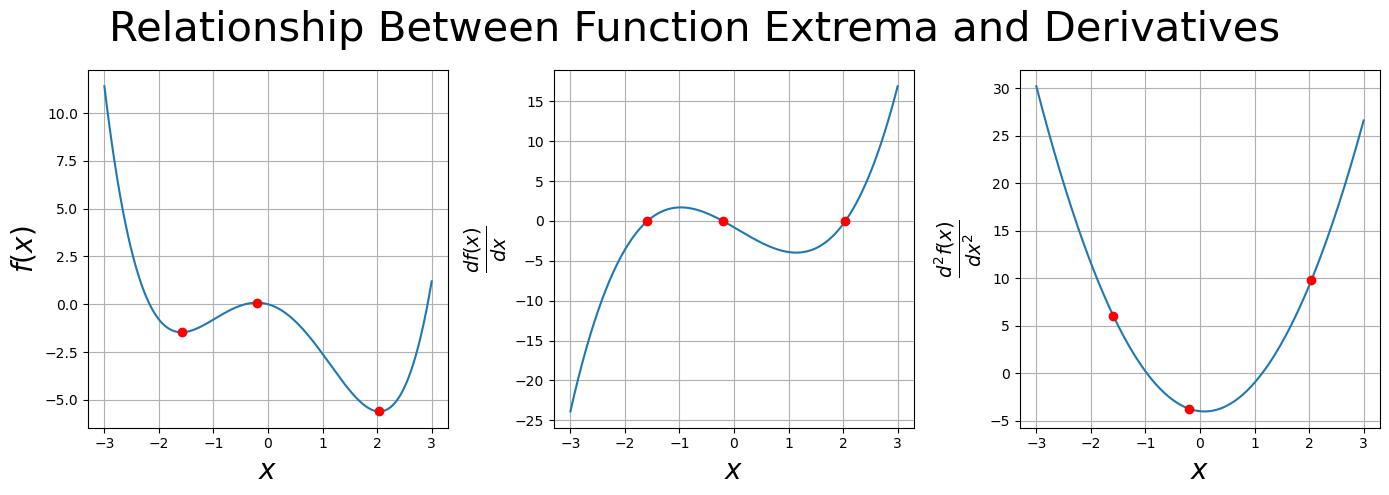

In [11]:
x = sym.Symbol('x')
# Example function
f = .3*x**4 - .1*x**3 -2*x**2 -.8*x 
# first and second derivative 
df = f.diff(x)
ddf=f.diff(x,2) 

# solve for exterma 
x_star = sym.solve(df, x)
# make sure to get real values 
x_star = np.array([ sym.re(val) for val in x_star])
print("extrema values", x_star)

# turn expressions into lambda functions 
f=sym.lambdify(x,f) 
df = sym.lambdify(x,df)
ddf=sym.lambdify(x,ddf) 

x=np.linspace(-3,3,500) 

# make plot 
fig=plt.figure(figsize=(14,5))
fig.suptitle("Relationship Between Function Extrema and Derivatives", size=30) 
ax=fig.add_subplot(131)
ax.set_xlabel(r"$x$", size=20) 
ax.set_ylabel(r"$f(x)$", size=20) 
ax.plot(x, f(x))
ax.plot(x_star, f(x_star), 'o', color="red") 
ax.grid()

ax=fig.add_subplot(132)
ax.set_xlabel(r"$x$", size=20) 
ax.set_ylabel(r"$\frac{df(x)}{dx}$", size=20) 
ax.plot(x, df(x))
ax.plot(x_star, df(x_star), 'o', color="red") 
ax.grid()

ax=fig.add_subplot(133)
ax.set_xlabel(r"$x$", size=20) 
ax.set_ylabel(r"$\frac{d^2f(x)}{dx^2}$", size=20) 
ax.plot(x, ddf(x))
ax.plot(x_star, ddf(x_star), 'o', color="red") 
ax.grid()

plt.tight_layout()

In [12]:
sym.re(x_star[0])

-1.58634606362263

## SymPy to the Rescue (if you forgot your derivatives)

[SymPy](https://www.sympy.org/en/index.html) is a Python library for symbolic mathematics. 
SymPy is a vast library, containing many useful symbolic operations that can be used for scientific computing. I will touch on some of the most basic operations you can perform in SymPy. Of course, you are free to fiddle with SymPy on your own, I am sure you will find many interesting SymPy capabilities. 

First, declare the symbols you will be using with the SymPy symbols function. Write your expression using SymPy functions (for example SymPy.cos). You can take the derivative with the expression.diff() method. Here are some example codes of taking derivatives of $f(x) = x^2 + \sin(x)$,  
\begin{equation} 
\begin{split} 
& f(x) = x^2 + \sin(x) \\
& \frac{df}{dx} = 2x + \cos(x) \\
& \frac{d^2f}{dx^2} = x - \sin(x) \\
& \frac{d^3f}{dx^3} = - \cos(x).
\end{split} 
\end{equation} 

In [13]:
x= sym.symbols("x") # declare a symbol for x

f=x**2 + sym.sin(x)   # symbolic equation 
f

x**2 + sin(x)

In [14]:
# fist derivative of f 
f.diff(x)

2*x + cos(x)

In [15]:
# second derivative of f
f.diff(x,2)

2 - sin(x)

In [16]:
# third derivative of f
f.diff(x,3)

-cos(x)

## Multivariate Functions and Partial Derivatives  

### Multivariate Function
A **multivariate function** is a function that takes **two or more variables** as inputs and produces a single output. In general a multivariate function maps from $ \mathbb{R}^n $ to $ \mathbb{R} $:$(f(x_1,~ x_2,~ ...~,~x_{n})$ 

Here are some two examples: 
* **Two-variable function**, $f(x,y) = x^2 + y^2$
* **Three-variable function**, $f(x,y,z)=x + 2y -z $


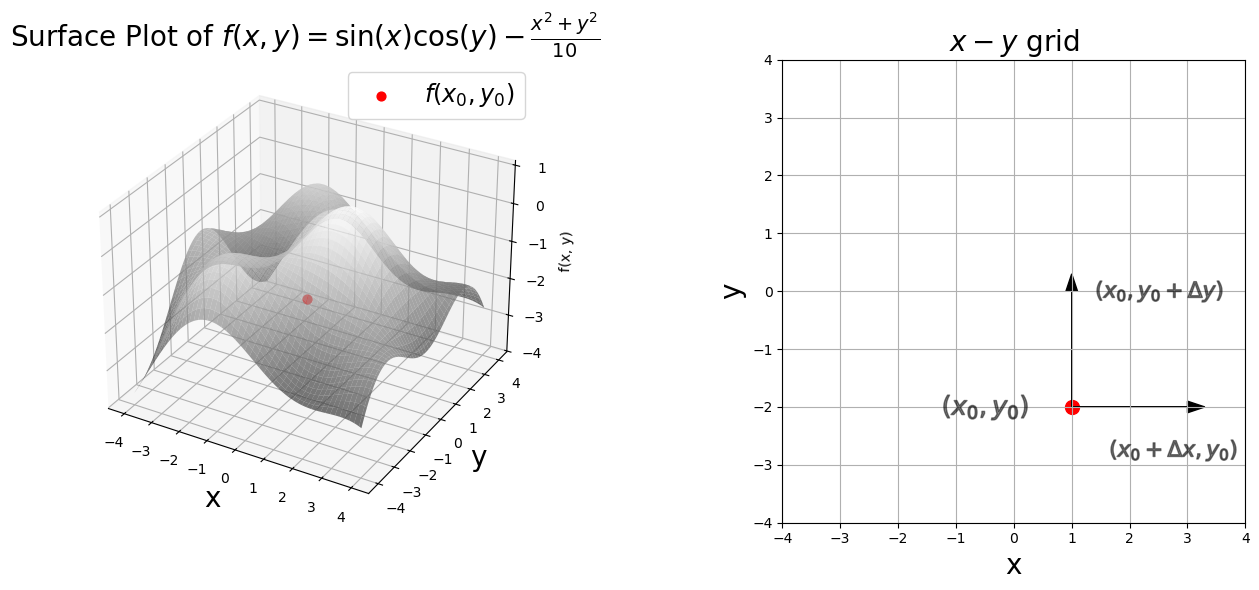

In [17]:
# Define the complex surface function
def f(x, y):
    return np.sin(x) * np.cos(y) + -(x**2 + y**2)/10 

# Create a grid of x and y values
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Plot the 3D surface
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='none', alpha=.7)

x0=1
y0=-2
f0=f(x0,y0)
ax.scatter(x0, y0, f0, color="red", s=40, label=r"$f(x_0, y_0)$")

# Add labels and title
ax.set_title(r'Surface Plot of $f(x, y) = \sin(x)\cos(y) - \frac{x^2 + y^2}{10}$', fontsize=20)
ax.set_xlabel('x', size=20)
ax.set_ylabel('y',size=20)
ax.set_zlabel('f(x, y)')
ax.legend(fontsize="xx-large")

# Plot the grid
ax=fig.add_subplot(122, aspect=True)
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
plt.xticks(np.arange(-4, 5, 1))
plt.yticks(np.arange(-4, 5, 1))

# Add a specific point at (x = 2, y = 1)
ax.scatter(x0, y0, color='red', s=100)
ax.arrow(x0, y0, 2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
ax.arrow(x0, y0, 0, 2, head_width=0.2, head_length=0.3, fc='black', ec='black')

ax.plot(-.5,-2, marker=r"$(x_0, y_0)$", markersize=60, color="black", alpha=.5)
ax.plot(2.75,-2.75, marker=r"$(x_0+\Delta x, y_0)$", markersize=90, color="black", alpha=.5)
ax.plot(2.5,0, marker=r"$(x_0, y_0 + \Delta y)$", markersize=90, color="black", alpha=.5)


ax.set_title(r"$x-y$ grid", size=20)
ax.set_xlabel("x", size=20)
ax.set_ylabel("y", size=20)
#ax.gca().set_aspect('equal')
ax.grid(True)
plt.tight_layout()


## Partial Derivatives
Above is the plot of the function
\begin{equation} 
f(x, y) = \sin(x)\cos(y) - \frac{x^2 + y^2}{10},
\end{equation} 
an upside-down paraboloid with oscillations, i.e., a lumpy hill. (Scroll up to see the plot.)

Let's take a stroll down imagination lane. Imagine the surface as a hill. The height of the hill above ground level corresponds $f(x,~y)$.  You are a surveyor, currently at position $(x_0,~ y_0)$, the red dot marked on the right plot below (the x-y grid). You record the height at $(x_0,~ y_0)$, let us call this $f_0=f(x_0,~ y_0)$ (this is the red dot on the left panel). You then take a step in the x-direction, $\Delta x$, maintaining your y-position at $y_0$. You measure the height at this location, $f(x_0 + \Delta x, y_0)$. Now you compute the slope from $x_0$ to $x_0 + \Delta x$, 
\begin{equation} 
\text{slope in x-direction} = \frac{f(x_0 + \Delta x, ~y_0) - f(x_0, ~y_0)}{\Delta x}. 
\end{equation} 
You return to your original location at $(x_0,~ y_0)$. You repeat the process but decrease your step $\Delta x$. Your measurement tools enable you to decrease the step $\Delta x$ as much as you like, however small you want to make it (this is imagination lane after all). In the limit as $\Delta x$ goes to zero, you have measured the partial derivative of $f(x,y)$ with respect to $x$ at the point $(x_0,~y_0)$, 

\begin{equation} 
\frac{\partial f}{\partial x} = \lim_{\Delta x \to 0}  \frac{f(x_0 + \Delta x,~ y_0) - f(x_0,~ y_0)}{\Delta x}.
\end{equation} 

Notice that you held the value of $y$ constant at $y_0$.

You return to your original location at $(x_0,~ y_0)$. You repeat the process but take step $\Delta y$ in the y-direction while maintaining your position at $x_0$. You construct a slope in the y-direction, 

\begin{equation} 
\text{slope in y-direction} = \frac{f(x_0 ,~ y_0 + \Delta y) - f(x_0, ~y_0)}{\Delta y}. 
\end{equation} 

You employ your ability to make $\Delta y$ as small as possible. You have measured the partial derivative of f(x,y) with respect to y at the point $(x_0,~y_0)$,

\begin{equation} 
\frac{\partial f}{\partial y} = \lim_{\Delta y \to 0}  \frac{f(x_0 ,~ y_0 + \Delta y) - f(x_0,~ y_0)}{\Delta y}.
\end{equation} 

#### Definition

Given a function $f(x_1, x_2, \dots, x_n)$, the **partial derivative** of $f$ with respect to $x_i$ is the derivative of $f$ treating all other variables $x_j$ ($j \neq i$) as constants, denoted by 

$$
\frac{\partial f}{\partial x_i}.
$$

You can reduce particle derivatives to the single variable case by keeping all but one variable constant. For example, consider the function, $f=f(x_1, x_2, x_3)$. Suppose we keep the last two slots constant, i.e., $x_2$ and $x_3$, and consider the single variable function, $g(t) = f(t, x_1, x_2)$. The partial derivative of $f$ with respect to $x_1$ is the derivative of the single variable function $g(t)$. 
 

**Interpretations**:
* It is the rate of change of $f$ in the direction of the $x_i$ axis, while all other variables are held constant.
* The partial derivative with respect to $x_i$ represents the slope of the function in the direction of the $x_i$-axis, holding all other $x_j$ constant.
  

#### Example

Let $f(x, y) = x^2y + 3xy^2$.

- The **partial derivative with respect to $x$** is found by treating $y$ as a constant:

$$
\frac{\partial f}{\partial x} = \frac{\partial}{\partial x} \left( x^2y + 3xy^2 \right) = 2xy + 3y^2
$$

- The **partial derivative with respect to $y$** is found by treating $x$ as a constant:

$$
\frac{\partial f}{\partial y} = \frac{\partial}{\partial y} \left( x^2y + 3xy^2 \right) = x^2 + 6xy
$$



#### Higher Order Partial Derivatives

Partial derivatives can be taken multiple times. For example, the second partial derivative of $f$ with respect to $x$ and $y$ is:

$$
\frac{\partial^2 f}{\partial x \partial y}
$$



#### Mixed Partial Derivatives

If the function is smooth enough, mixed partial derivatives are equal. That is, if $f(x, y)$ has continuous second partial derivatives:

$$
\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}
$$

This is known as **[Clairaut's Theorem](https://en.wikipedia.org/wiki/Symmetry_of_second_derivatives)**.


#### Back to the initial example
Let's go back to the initial example, 

\begin{equation} 
f(x, y) = \sin(x)\cos(y) - \frac{x^2 + y^2}{10}.
\end{equation} 

I could write out the partial derivatives here, well, "to heck with that", I will just use SymPy. See the code below. I will let you to check if SymPy is correct.


In [18]:
x, y = sym.symbols("x y") 
f=sym.sin(x)*sym.cos(y) - (x**2 +y**2)/10 

In [19]:
# partial derivative with respect to x
f.diff(x) 

-x/5 + cos(x)*cos(y)

In [20]:
# partial derivative with respect to y
f.diff(y) 

-y/5 - sin(x)*sin(y)

In [21]:
# second partial derivative with respect to x
f.diff(x,2) 

-(sin(x)*cos(y) + 1/5)

In [22]:
# second partial derivative with respect to y
f.diff(y,2)

-(sin(x)*cos(y) + 1/5)

In [23]:
# second partial derivative with respect to x and y, f_{x,y}, method 1
sym.diff(f,x,y)

-sin(y)*cos(x)

In [24]:
# second partial derivative with respect to x and y, f_{x,y}, method 2
f.diff(x,y)

-sin(y)*cos(x)

In [25]:
# second partial derivative with respect to x and y, f_{x,y}, method 3
f.diff(x,y)
f.diff(x).diff(y)

-sin(y)*cos(x)

## The Gradient 

The **gradient** of a scalar function $f(x_1,x_2,...,x_n)$ is a vector that contains all the  partial derivatives of $f$ with respect to $x_1,x_2,...,x_n$,

\begin{equation}
\nabla f(x_1, x_2, ..., x_n) = \begin{bmatrix}\frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}.
\end{equation}

The symbol for the gradient is called the nabla or dell operator $\nabla$ (the upside down triangle). 

For a function of two variables:  
\begin{equation}
f(x, y)
\end{equation}

The gradient is:  
\begin{equation}
\nabla f(x, y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix} 
\end{equation}


#### Interpretation

Back to imagination lane. Recall you are a surveyor, measuring the change in height of a hill; think of $f(x,~y)$ as the height map. The partial derivative in the x-direction measures the rate of change of height as you move in the x-direction. The partial derivative in the y-direction measures the rate of change of height as you move in the y-direction. 

You ask yourself a question, "In which direction should I walk so that the path I take is the steepest?" (Ignoring the fact that no one would want to take the steepest path, again, it's imagination lane here). Now you don't have to walk in either the x or y directions, you can choose a path in any direction. The direction you should choose is the direction of the gradient.

- The gradient points in the direction of the **steepest rate of increase** of the function (often called the direction of steepest ascent) 
- The gradient tells us **how the function changes** in each direction at a given point.
- It is **perpendicular to level curves** (contour lines) of the function.


#### Optimization and the Gradient 

In optimization, we don't want to move in the direction that the function (i.e. the loss function) increases most rapidly. We want to move in the direction of the most rapid decrease, as we are trying to get to the minima of the loss function ("what I call the bottom of things"). This means we should move in the direction of the negative of the gradient. We can write the optimiation rule as 

\begin{equation} \text{new location = current location - the gradient of the loss function.}
\end{equation} 

Gradient descent is one of the most common optimization algorithms. The gradient desent rule looks like this
\begin{equation} 
\mathbf{x}_{n+1} = \mathbf{x}_n - \eta \nabla L,
\end{equation}
where $L$ is the loss function, $\mathbf{x}_n$ are the function paramters at step $n$, likewise, $\mathbf{x}_{n+1}$ are the function parameters at step $n+1$, and $\eta$ is called the learning rate, which controls how large of a step to take. 

#### Example of a Gradient 

Let:  
\begin{equation}
f(x, y) = x^2y + \sin(xy)
\end{equation}

Then:  
\begin{equation}
\frac{\partial f}{\partial x} = 2xy + y\cos(xy)
\end{equation}  
\begin{equation}
\frac{\partial f}{\partial y} = x^2 + x\cos(xy)
\end{equation}

So the gradient is:  
\begin{equation}
\nabla f(x, y) = \begin{bmatrix} 2xy + y\cos(xy) \\\ x^2 + x\cos(xy) \end{bmatrix} 
\end{equation}

Here is the above example in SymPy. 

In [26]:
x, y = sym.symbols("x y") 
f =  x**2*y + sym.sin(x*y)

df = sym.Matrix([f.diff(val) for val in (x,y)])
df

Matrix([
[2*x*y + y*cos(x*y)],
[ x**2 + x*cos(x*y)]])

## The Jacobian 
For a function $f : \mathbb{R}^n \to \mathbb{R}^m$, the Jacobian is defined as
\begin{equation} 
J_f =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}.
\end{equation}

The elements in index notation for the Jacobian are
\begin{equation} 
[J_f]_{ij} = \frac{\partial f_i}{\partial x_j}.
\end{equation} 

The i-th row of the Jacobian is the gradient of $f_i$. 

#### example 
Consider the vector valued function 
\begin{equation} 
\mathbf{f}(x,y) = \begin{bmatrix} x^2 + y^2 \\ x^2 + xy \end{bmatrix} .
\end{equation} 

The Jacobian is 
\begin{equation} 
J_f = \begin{bmatrix} 2x & 2y \\
2x + y & x 
\end{bmatrix} 
\end{equation} 

Here is the above example in SymPy.

In [27]:
x, y = sym.symbols('x y')

# Define a vector-valued function (e.g., f(x, y) = [x^2 * y, sin(x + y)])
f1 = x**2  + y**2
f2 = x**2 + x*y 

# Create the vector-valued function
f = sym.Matrix([f1, f2])

# Compute the Jacobian matrix
jacobian_matrix = f.jacobian([x, y])

f

Matrix([
[x**2 + y**2],
[ x**2 + x*y]])

In [28]:
jacobian_matrix

Matrix([
[    2*x, 2*y],
[2*x + y,   x]])

## Hessian 
The **Hessian matrix** is a square matrix of second-order partial derivatives of a scalar function. Given a twice-differentiable function $( f: \mathbb{R}^n \to \mathbb{R} )$, the Hessian matrix $H$ is defined as:


\begin{equation}
H_f=
\begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} & \frac{\partial^2 f}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}
\end{equation} 

\begin{equation} 
[H_f]_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}
\end{equation} 

#### Interpretation
When we considered functions of a single variable, we learned that the second derivative contained information about the curvature of the curve. Likewise, the Hessian contains information about the local curvature of the multivariate function. 

#### example 
\begin{equation} 
f(x, y) = x^3 + y^2 + xy
\end{equation} 

Computing second-order derivatives:

\begin{equation} 
\frac{\partial^2 f}{\partial x^2} = \frac{\partial}{\partial x} (3x^2 + y) = 6x
\end{equation} 

\begin{equation} 
\frac{\partial^2 f}{\partial y^2} = \frac{\partial}{\partial y} (2y + x) = 2
\end{equation} 

\begin{equation} 
\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial}{\partial y} (3x^2 + y) = 1
\end{equation} 

\begin{equation} 
\frac{\partial^2 f}{\partial y \partial x} = \frac{\partial}{\partial x} (2y + x) = 1
\end{equation} 

\begin{equation} 
H_f= \begin{bmatrix} 6x & 1 \\
1 & 2 \end{bmatrix} 
\end{equation} 

Here is the SymPy code for the example above. 

In [29]:
# Define the variables
x, y = sym.symbols('x y')

# Define a scalar-valued function (e.g., f(x, y) = x^2 + y^2)
f = x**3 + y**2 + x*y

# Compute the Hessian matrix
hessian_matrix = sym.hessian(f, [x, y])
hessian_matrix 

Matrix([
[6*x, 1],
[  1, 2]])

## The Chain Rule

The chain rule is used to compute the derivative of composite functions.

For a composite function $f=f(g(x))$ the chain rule provides the derivative:
\begin{equation} 
\frac{df}{dx} = \frac{d f}{d g}\frac{d g}{d x}. 
\end{equation} 

#### Example 
Let us consider a composite operation composed of a linear transformation of input data $x$ followed by a non-linear transformation,  
\begin{equation} 
\begin{split} 
& z = \beta_0 + \beta_1 x , \quad \text{linear transformation of $x$} \\
& y  = \sigma(z)  , \quad \text{non linear transformation of $z$} \\
& \sigma(z) = \frac{1}{1 + e^{-z}} 
\end{split} 
\end{equation} 
where $y$ is the output data and $\sigma$ is called the sigmoid function. 

We want the partial derivatives of $y$ with respect to the model parameters $\beta_0$ and $\beta_1$: 

\begin{equation} 
\begin{split} 
& \frac{\partial y}{\partial \beta_0} = \frac{\partial \sigma}{\partial z} \frac{\partial z}{\partial \beta_0} \\
& \frac{\partial y}{\partial \beta_1} = \frac{\partial \sigma}{\partial z} \frac{\partial z}{\partial \beta_1} . 
\end{split} 
\end{equation} 

We compute each term individually. 

\begin{equation}
\begin{split} 
& \frac{\partial \sigma}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2} \\
& \frac{\partial z}{\partial \beta_0} = 1 \\
& \frac{\partial z}{\partial \beta_1} =1 .
\end{split} 
\end{equation}

We now have: 
\begin{equation} 
\begin{split} 
& \frac{\partial y}{\partial \beta_0} = \frac{e^{-\beta_0 - \beta_1 x}}{(1 + e^{-\beta_0 - \beta_1 x})^2}  \\
& \frac{\partial y}{\partial \beta_1} = \frac{xe^{-\beta_0 - \beta_1 x}}{(1 + e^{-\beta_0 - \beta_1 x})^2} .  
\end{split} 
\end{equation} 

Below, I checked the result in SymPy. 

In [31]:
x,z,beta_1, beta_0 = sym.symbols("x z beta_1 beta_0") 

z=beta_0 + beta_1 *x 
z

beta_0 + beta_1*x

In [32]:
y = 1/(1 + sym.exp(-z)) 
y 

1/(exp(-beta_0 - beta_1*x) + 1)

In [33]:
y.diff(beta_0) 

exp(-beta_0 - beta_1*x)/(exp(-beta_0 - beta_1*x) + 1)**2

In [34]:
y.diff(beta_1) 

x*exp(-beta_0 - beta_1*x)/(exp(-beta_0 - beta_1*x) + 1)**2

## Taylor Series 
It would be an understatement to say that the Taylor series is important in numerical methods. In a standard numerical methods course, I feel like you are doing a Taylor series in every class. 

The Taylor series of a continous fucntion is 
\begin{equation}
f(x + \Delta x) = f(x) + f^{(1)}(x)\Delta x + \frac{f^{(2)}(x)}{2!}\Delta x^2 + \frac{f^{(3)}(x)}{3!}\Delta x^3 + \cdots, 
\end{equation}
where $f^{(n)} = \frac{ d^nf}{dx^n}$ is the n-the derivative of $f$. In summation form, the Taylor series is
\begin{equation} 
f(x + \Delta x) = \displaystyle \sum_{n=0}^\infty \frac{1}{n!} f^{(n)}(x) \Delta x^n.
\end{equation} 

What does the Taylor series say? 
* If we know the function and all its derivatives at the point $x$, then we know the function at the point $x + \Delta x$. 
* A Taylor series is a power series representation of the function, i.e., it writes the function as a summation of powers of $\Delta x$

In practice it is often inpractical to take an infinite sum (shocker!). More likely a truncated Taylor series is taken, meaning that the infinite sum is truncated at a particular n-value. Here is series truncated at $n=2$ 
\begin{equation} 
f(x + \Delta x) = f(x) + f^{(1)}(x)\Delta x + \frac{f^{(2)}(x)}{2!}\Delta x^2 + \mathcal{O}(\Delta x^3). 
\end{equation} 
#### Example 
The Taylor series for $\sin(x)$ is 
\begin{equation}
\sin x = \sum_{n=0}^{\infty} \frac{(-1)^n}{(2n+1)!} x^{2n+1}
= x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \cdots.
\end{equation}

Below I plot truncated Taylor series approximations to sin(x). 

In [35]:
x = np.linspace(-2*np.pi, 2*np.pi, 1000) 

y0=x
y1=y0 - x**3/factorial(3) 
y2=y1 + x**5/factorial(5) 
y3=y2 - x**7/factorial(7) 

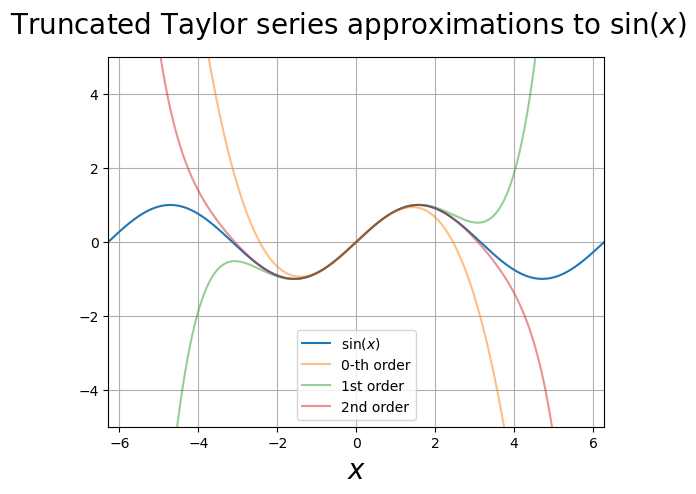

In [36]:
fig=plt.figure()
fig.suptitle(r"Truncated Taylor series approximations to $\sin(x)$", size=20)
ax=fig.add_subplot()
ax.set_ylim(-5,5)
ax.set_xlim(x[0], x[-1]) 
ax.set_xlabel(r"$x$", size=20) 
ax.plot(x, np.sin(x), label =r"$\sin(x)$")
ax.plot(x, y1, alpha=.5, label="0-th order") 
ax.plot(x, y2, alpha=.5, label="1st order") 
ax.plot(x, y3, alpha=.5, label="2nd order") 
ax.grid()
ax.legend()

An example of using SymPy to get the Taylor series expansion of a function. 

In [37]:
# Define the symbol
x = sym.symbols('x')

# sin(x) example 
f = sym.sin(x)

# Taylor series expansion of sin(x) around x = 0 up to order 7
taylor_series = f.series(x, 0, 8)
taylor_series

x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)

In [38]:
# cos(x) example 
f = sym.cos(x)

# Taylor series expansion of cos(x) around x = 0 up to order 7
taylor_series = f.series(x, 0, 8)
taylor_series

1 - x**2/2 + x**4/24 - x**6/720 + O(x**8)

In [39]:
# sigmoid function example 
f = 1/(1 + sym.exp(-x))

# Taylor series expansion for sigmoid function around x = 0 up to order 7
taylor_series = f.series(x, 0, 8)
taylor_series

1/2 + x/4 - x**3/48 + x**5/480 - 17*x**7/80640 + O(x**8)

### Taylor Series with Remainder 


The Taylor series expansion of a function $f(x + \Delta x)$ around a point $ x $ is given by:

\begin{equation} 
f(x + \Delta x) = f(x) + f^{(1)}(x)\Delta x + \frac{f^{(2)}(x)}{2!}\Delta x + \frac{f^{(3)}(x)}{3!}\Delta x^3 + \dots + \frac{f^{(n)}(x)}{n!}\Delta x^n + R_n(x)
\end{equation} 

Where:
- $ R_n(x)$ is the **remainder term** or **error term** that indicates the difference between the exact value and the approximation. 
- The remainder $R_n(x)$ can be written as:

\begin{equation} 
R_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\Delta x^{n+1}
\end{equation} 

where $\xi $ is some point in the interval between $x$ and $x + \Delta x$.

A general use case is to approximate a function with a truncated Taylor series. The remainder term provides information on how accurate the approximation is. 

## Multivariable Taylor Series

A multivariable function has a Taylor series given by, 
\begin{equation} 
f(\mathbf{x} + \mathbf{\Delta x}) = f(\mathbf{x}) + \nabla f(\mathbf{x}) \cdot \mathbf{\Delta x} + \frac{1}{2} \mathbf{\Delta x}^T H_f(\mathbf{x}) \mathbf{\Delta x} + \cdots.
\end{equation} 


Explanation:

$\mathbf{x} = \left[ x_1, x_2, ..., x_n\right]^T$:  A vector representing the point at which the Taylor series is expanded. 

$\mathbf{\Delta x}= \left[\Delta x_1, \Delta x_2, ..., \Delta x_n\right]^T$: A vector representing the displacement from \mathbf{x}.

$f(\mathbf{x})$: The value of the function at \mathbf{x}.

$\nabla f(\mathbf{x})$: The gradient of f at $\mathbf{x}$, which is a vector of the first partial derivatives.

$\nabla f(\mathbf{x}) \cdot \mathbf{\Delta x}$: The dot product of the gradient and the displacement vector.

$H_f(\mathbf{x})$: The Hessian matrix of f at $\mathbf{x}$, which is a matrix of the second partial derivatives.

$\mathbf{\Delta x}^T$: The transpose of the displacement vector.

$\frac{1}{2} \mathbf{\Delta x}^T H_f(\mathbf{x}) \mathbf{\Delta x}$: A quadratic form involving the Hessian and the displacement vector.

$\cdots$: Represents higher-order terms in the expansion.